In [130]:
import torch
%pip install torch_harmonics
from src.models.tfno import TFNO2D
from src.models.fno import LatentFNO
%pip install tqdm
from src.models.dmd import HankelDMDModel, MyPCA

from src.utils import load_data, spectral_downsample_2d, spectral_upsample_2d

from src.viz import plot_weather, plot_loss_curve, plot_multistep_error_barplot, plot_multistep_error_boxplot, \
    plot_mean_nstep_error_map, plot_multistep_comparison_boxplot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ImportError: cannot import name 'plot_mean_nstep_error_map' from 'src.viz' (D:\Маша\TUDO\11 семестр\Data Science for Dynamical Systems\DS4DS-Final-Project\src\viz.py)

In [2]:
import pandas as pd
import numpy as np

## Data

In [40]:
# Raw data
test = load_data(train=False)
torch_test = torch.from_numpy(test).float()
B, T, C, H, W = test.shape

# Latent representation
latent_dim = 128
pca = MyPCA(n_components=latent_dim)
pca = pca.load("checkpoints/pca.pkl")

# Transform test data to latent space
transformed_test = pca.transform(torch_test.reshape(B*T, C*H*W)).reshape(B, T, latent_dim)

Found 4 files in test directory.
Loaded data shape: (4, 1008, 2, 128, 256)


D:\Anaconda\envs\dmc25\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator IncrementalPCA from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## DMD


In [41]:
t_hist, t_rollout = 12, 240

dmd = HankelDMDModel(latent_dim, delays=t_hist)
dmd = dmd.load("checkpoints/dmd.pkl")

Original shape: (1, 12, 128)
Predicted shape: (1, 240, 128)
Inverse-transformed shape: (1, 240, 2, 128, 256) (1, 240, 2, 128, 256)


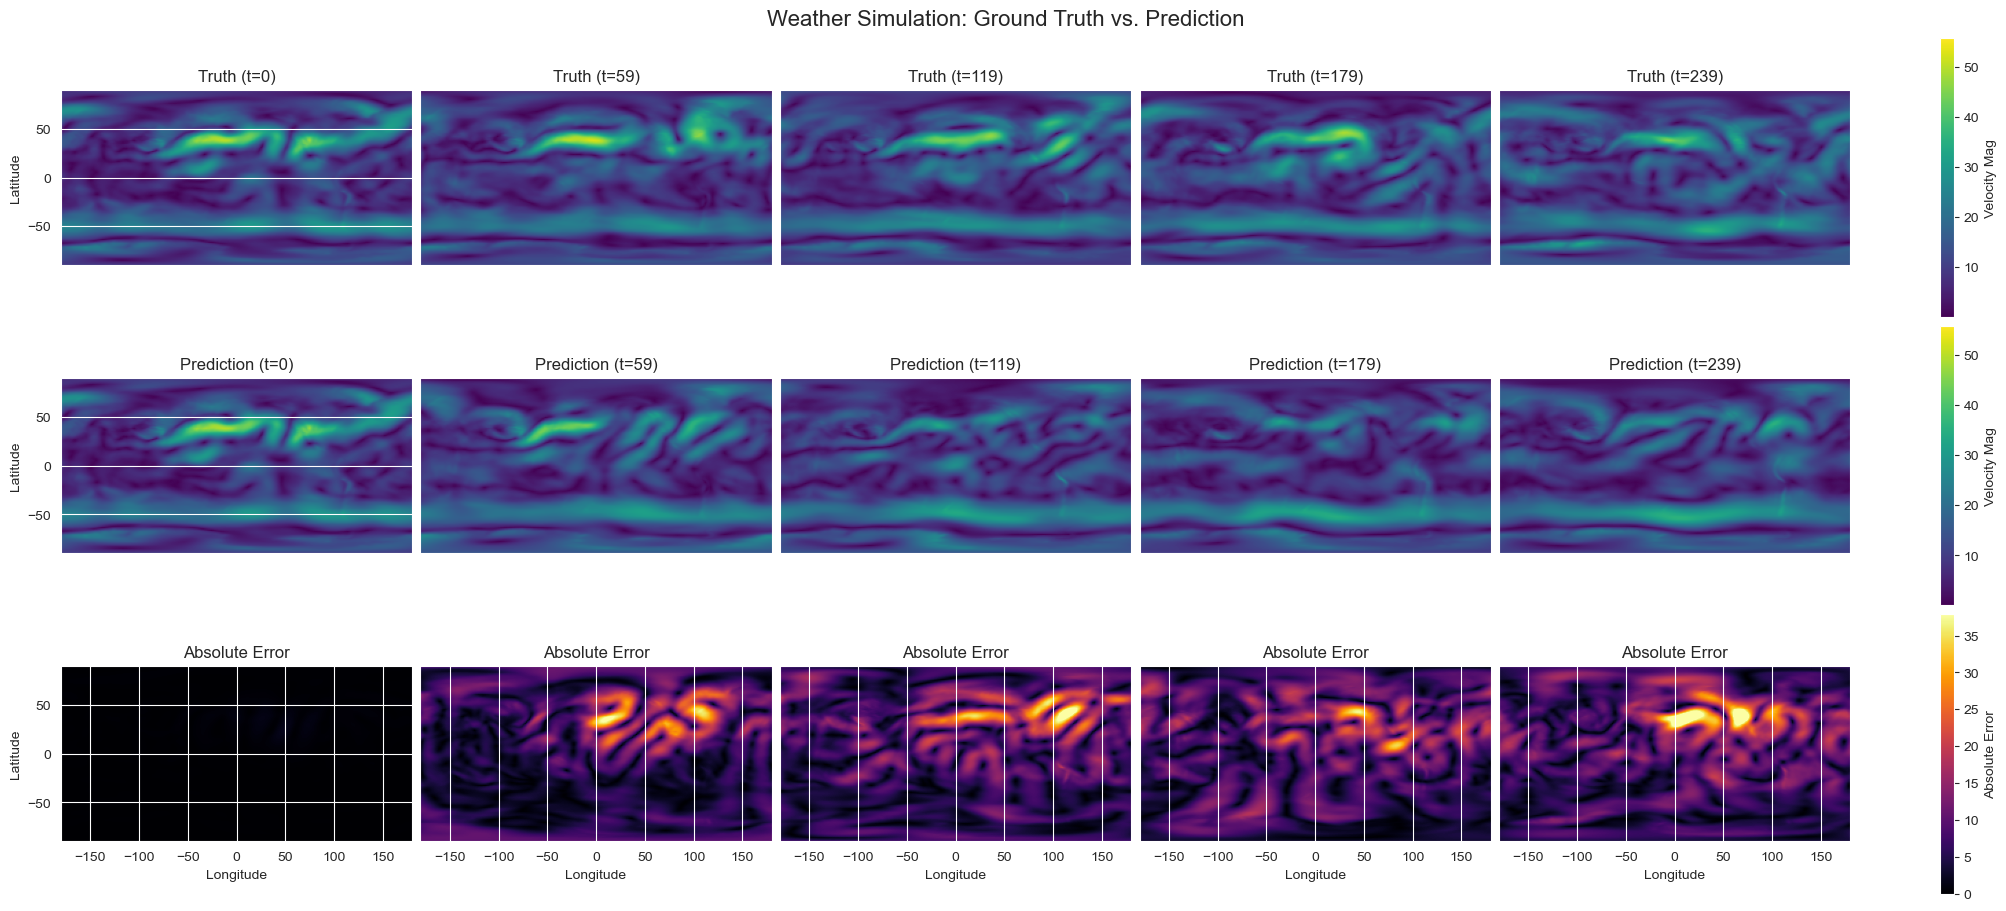

In [42]:
## Predict with DMD

x = transformed_test[0:1, :t_hist]
print("Original shape:", x.shape)
pred_dmd = dmd.predict(x, t_rollout)
print("Predicted shape:", pred_dmd.shape)

# Inverse transform to original space
y_true = transformed_test[0:1, t_hist:t_hist+t_rollout]
y_true = pca.inverse_transform(y_true.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
pred_dmd = pca.inverse_transform(pred_dmd.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
#print("Inverse-transformed shape:", y_true.shape, pred_dmd.shape)

# Plot
plot_weather(y_true[0], pred_dmd[0], num_steps=5)

In [43]:
# Predict with DMD
t_hist, t_rollout = 12, 168
n_steps = [0, 3, 23, 71, 167]

# Inverse transform to original space
y_true = transformed_test[0:1, t_hist:t_hist+t_rollout]
y_true = pca.inverse_transform(y_true.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)

pred_ls = []
y_true_ls = []

for j in range(0, B):
    if j == B - 1:
        x = transformed_test[j:, :t_hist]
    else:
        x = transformed_test[j:j+1, :t_hist]
    print("Original shape:", x.shape)

    pred_traj = dmd.predict(x, t_rollout)
    print("Predicted shape:", pred_traj.shape)

    # Inverse transform to original space
    pred_traj = pca.inverse_transform(pred_traj.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
    print("Inverse-transformed shape:", pred_traj.shape)

    pred_ls.append(pred_traj)

    if j == B - 1:
        y_true_traj = transformed_test[j:, t_hist:t_hist+t_rollout]
    else:
        y_true_traj = transformed_test[j:j+1, t_hist:t_hist+t_rollout]

    y_true_traj = pca.inverse_transform(y_true_traj.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
    print("Inverse-transformed shape of y:", y_true_traj.shape)

    y_true_ls.append(y_true_traj)

pred_dmd = np.stack(pred_ls, axis = 0).squeeze()
print("Predicted shape all trajectories:", pred_dmd.shape)
y_true_dmd = np.stack(y_true_ls, axis = 0).squeeze()
print("True shape all trajectories:", y_true_dmd.shape)

Original shape: (1, 12, 128)
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: (1, 168, 2, 128, 256)
Original shape: (1, 12, 128)
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: (1, 168, 2, 128, 256)
Original shape: (1, 12, 128)
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: (1, 168, 2, 128, 256)
Original shape: (1, 12, 128)
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: (1, 168, 2, 128, 256)
Predicted shape all trajectories: (4, 168, 2, 128, 256)
True shape all trajectories: (4, 168, 2, 128, 256)


## LatentFNO

In [44]:
t_hist, t_rollout = 1, 240

# Transform test data to latent space
transformed_test_torch = torch.from_numpy(transformed_test).float()

fno = LatentFNO(latent_dim=latent_dim,
                t_hist=t_hist,
                width=64, modes=32,
                n_layers=4).to(device)
fno.eval()
fno_state_dict = torch.load("checkpoints/fno.pth", map_location=torch.device('cpu'))

Original shape: torch.Size([1, 1, 128])
Predicted shape: (1, 240, 128)


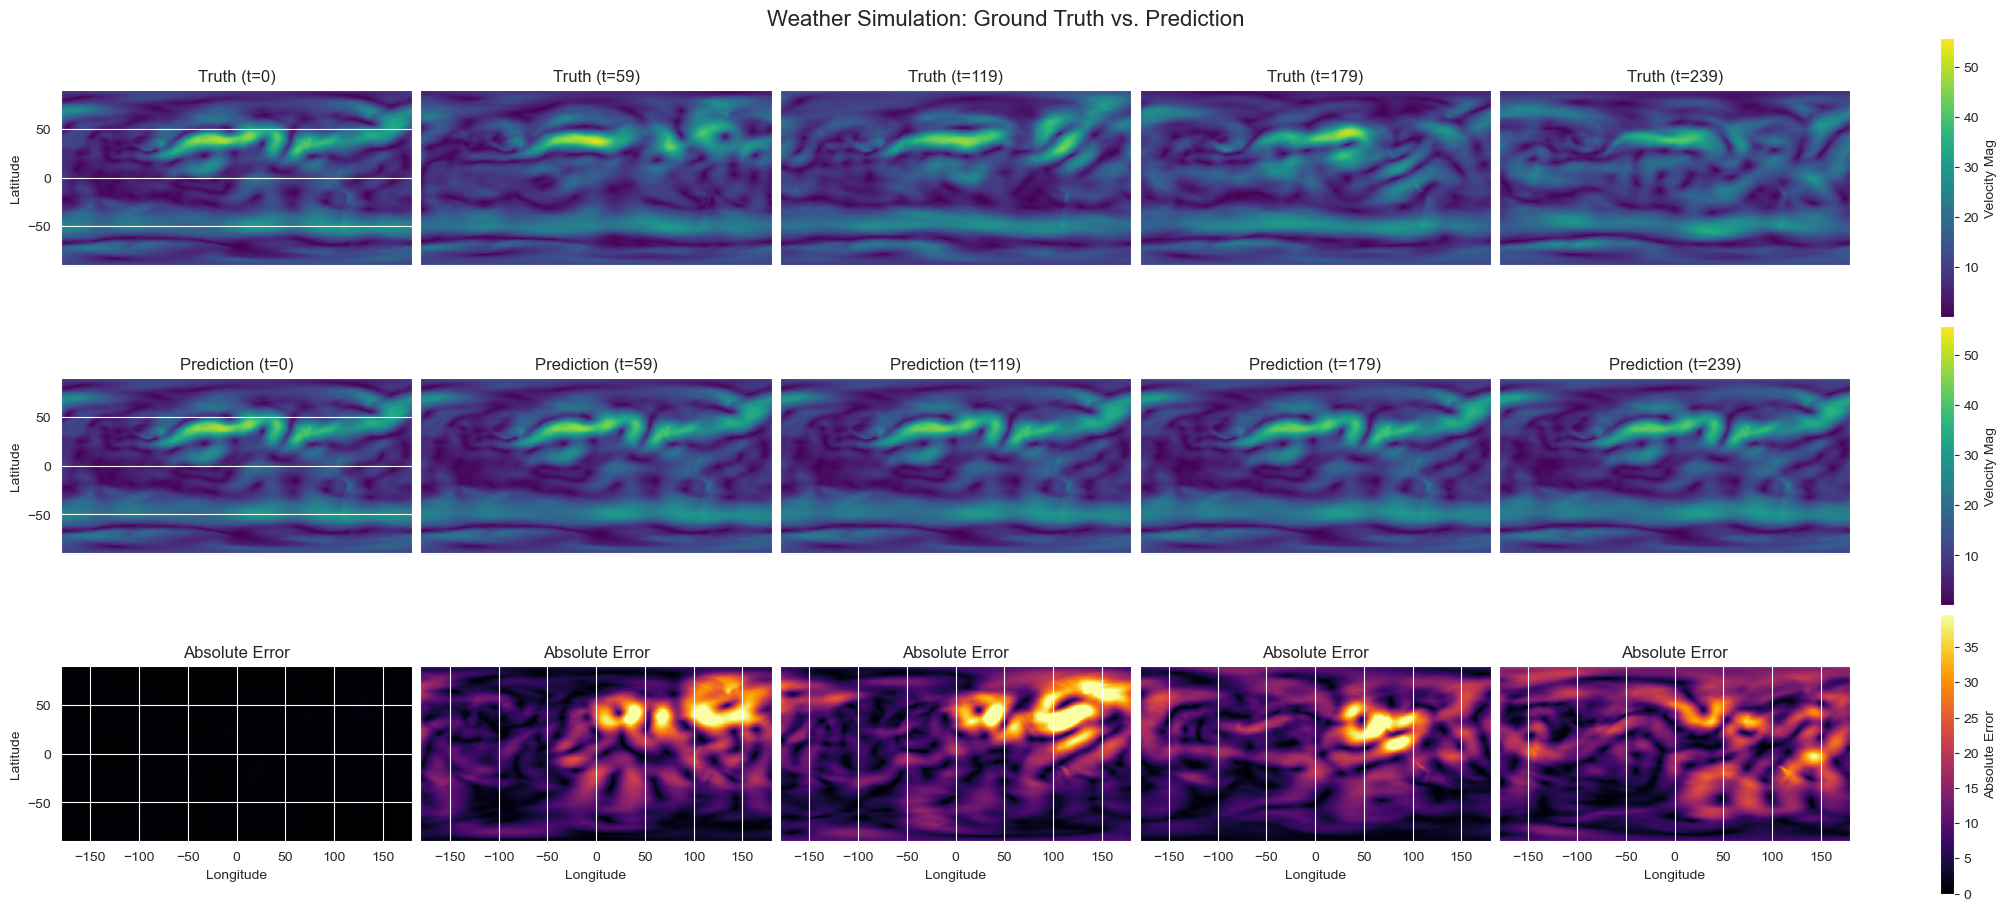

In [45]:
# Predict with LatentFNO
x = transformed_test_torch[0:1, :t_hist].to(device)
print("Original shape:", x.shape)
with torch.no_grad():
    t_grid = torch.arange(t_hist, t_hist+t_rollout).float().unsqueeze(0).unsqueeze(-1).to(x.device)
    pred_fno = fno(x, t_grid, steps=t_rollout).detach().cpu().numpy()
print("Predicted shape:", pred_fno.shape)

# Inverse transform to original space
y_true = transformed_test_torch[0:1, t_hist:t_hist+t_rollout].cpu().numpy()
y_true = pca.inverse_transform(y_true.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
pred_fno = pca.inverse_transform(pred_fno.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)

# Plot
plot_weather(y_true[0], pred_fno[0], num_steps=5)

In [46]:
# Predict with LatentFNO
t_hist, t_rollout = 1, 168
n_steps = [0, 3, 23, 71, 167]

pred_ls = []
y_true_ls = []

for j in range(0, B):
    if j == B - 1:
        x = transformed_test_torch[j:, :t_hist].to(device)
    else:
        x = transformed_test_torch[j:j+1, :t_hist].to(device)
    print("Original shape:", x.shape)

    with torch.no_grad():
        t_grid = torch.arange(t_hist, t_hist+t_rollout).float().unsqueeze(0).unsqueeze(-1).to(x.device)
        pred_traj = fno(x, t_grid, steps=t_rollout).detach().cpu().numpy()
    print("Predicted shape:", pred_traj.shape)

    # Inverse transform to original space
    pred_traj = pca.inverse_transform(pred_traj.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
    print("Inverse-transformed shape:", pred_traj.shape)

    pred_ls.append(pred_traj)

    if j == B - 1:
        y_true_traj = transformed_test_torch[j:, t_hist:t_hist+t_rollout].to(device)
    else:
        y_true_traj = transformed_test_torch[j:j+1, t_hist:t_hist+t_rollout].to(device)

    y_true_traj = pca.inverse_transform(y_true_traj.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
    print("Inverse-transformed shape of y:", y_true_traj.shape)

    y_true_ls.append(y_true_traj)

pred_fno = np.stack(pred_ls, axis = 0).squeeze()
print("Predicted shape all trajectories:", pred_fno.shape)
y_true_fno = np.stack(y_true_ls, axis = 0).squeeze()
print("Predicted shape all trajectories:", y_true_fno.shape)

Original shape: torch.Size([1, 1, 128])
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: torch.Size([1, 168, 2, 128, 256])
Original shape: torch.Size([1, 1, 128])
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: torch.Size([1, 168, 2, 128, 256])
Original shape: torch.Size([1, 1, 128])
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: torch.Size([1, 168, 2, 128, 256])
Original shape: torch.Size([1, 1, 128])
Predicted shape: (1, 168, 128)
Inverse-transformed shape: (1, 168, 2, 128, 256)
Inverse-transformed shape of y: torch.Size([1, 168, 2, 128, 256])
Predicted shape all trajectories: (4, 168, 2, 128, 256)
Predicted shape all trajectories: (4, 168, 2, 128, 256)


## TFNO

In [47]:
t_hist, t_rollout = 1, 240

# Spectral downsampling
factor = 8
H_2, W_2 = H // factor, W // factor
print("Original shape:", torch_test.shape)
downsampled = spectral_downsample_2d(torch_test.view(-1, C, H, W), factor).view(B, T, C, H_2, W_2)
print("Downsampled shape:", downsampled.shape)

# TFNO
tfno = TFNO2D(
    factor=factor, in_channels=C, out_channels=C,
    in_time=t_hist, out_time=t_rollout,
    width=16,
    depth=4,
    modes_h=64,
    modes_w=32,
    factorization="tucker"
).to(device) 
tfno.eval()
tfno_state_dict = torch.load("checkpoints/tfno.pth", map_location=device)

Original shape: torch.Size([4, 1008, 2, 128, 256])
Downsampled shape: torch.Size([4, 1008, 2, 16, 32])


Original shape: torch.Size([1, 1, 2, 16, 32])
Predicted shape: torch.Size([1, 240, 2, 16, 32])
Upsampled shape: torch.Size([1, 240, 2, 128, 256])


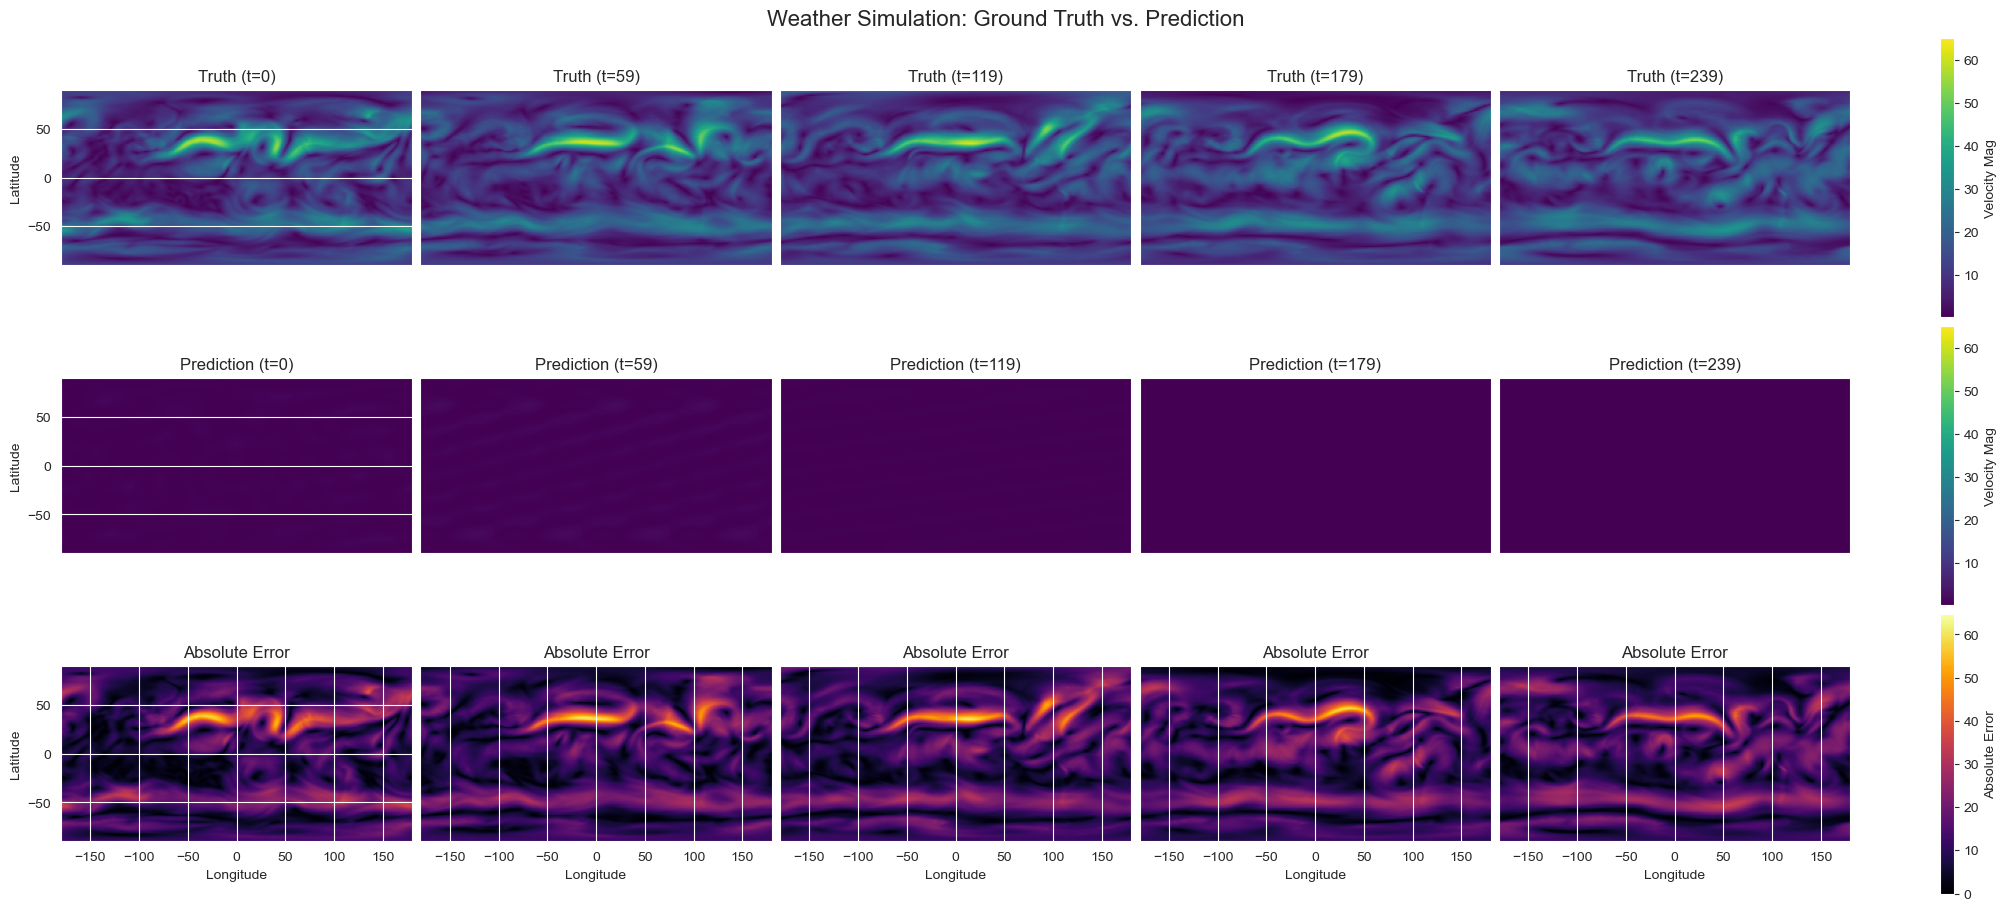

In [48]:
# Predict with TFNO
t_hist, t_rollout = 1, 240
x = downsampled[0:1, :t_hist].to(device)
print("Original shape:", x.shape)
t_grid = torch.zeros((1, 1)).float().to(x.device)
with torch.no_grad():
    pred_tfno = tfno(x, t_grid, steps=t_rollout).detach().cpu()
print("Predicted shape:", pred_tfno.shape)

# Spectral upsampling
pred_tfno_upsampled = spectral_upsample_2d(pred_tfno.view(-1, C, H_2, W_2), factor).view(1, t_rollout, C, H, W)
print("Upsampled shape:", pred_tfno_upsampled.shape)

# Plot
y_true = torch_test[0:1, t_hist:t_hist+t_rollout].cpu().numpy()
plot_weather(y_true[0], pred_tfno_upsampled[0].cpu().numpy(), num_steps=5)

In [59]:
# Predict with TFNO
t_hist, t_rollout = 1, 168
n_steps = [0, 3, 23, 71, 167]

pred_ls = []

for j in range(0, B):
    if j == B - 1:
        x = downsampled[j:, :t_hist].to(device)
    else:
        x = downsampled[j:j+1, :t_hist].to(device)
    print("Original shape:", x.shape)

    t_grid = torch.zeros((1, 1)).float().to(x.device)
    with torch.no_grad():
        pred_traj = tfno(x, t_grid, steps=t_rollout).detach().cpu()
    print("Predicted shape:", pred_traj.shape)

    # Spectral upsampling
    pred_traj_upsampled = spectral_upsample_2d(pred_traj.view(-1, C, H_2, W_2), factor).view(1, t_rollout, C, H, W)
    print("Upsampled shape:", pred_traj_upsampled.shape)

    pred_ls.append(pred_traj_upsampled)

pred_tfno = np.stack(pred_ls, axis = 0).squeeze()
print("Predicted shape all trajectories:", pred_tfno.shape)

y_true_tfno = torch_test.cpu().numpy()[::, :t_rollout]
print("True shape all trajectories:", y_true_tfno.shape)

Original shape: torch.Size([1, 1, 2, 16, 32])
Predicted shape: torch.Size([1, 168, 2, 16, 32])
Upsampled shape: torch.Size([1, 168, 2, 128, 256])
Original shape: torch.Size([1, 1, 2, 16, 32])
Predicted shape: torch.Size([1, 168, 2, 16, 32])
Upsampled shape: torch.Size([1, 168, 2, 128, 256])
Original shape: torch.Size([1, 1, 2, 16, 32])
Predicted shape: torch.Size([1, 168, 2, 16, 32])
Upsampled shape: torch.Size([1, 168, 2, 128, 256])
Original shape: torch.Size([1, 1, 2, 16, 32])
Predicted shape: torch.Size([1, 168, 2, 16, 32])
Upsampled shape: torch.Size([1, 168, 2, 128, 256])
Predicted shape all trajectories: (4, 168, 2, 128, 256)
True shape all trajectories: (4, 168, 2, 128, 256)


## Multi-step prediction error - single models

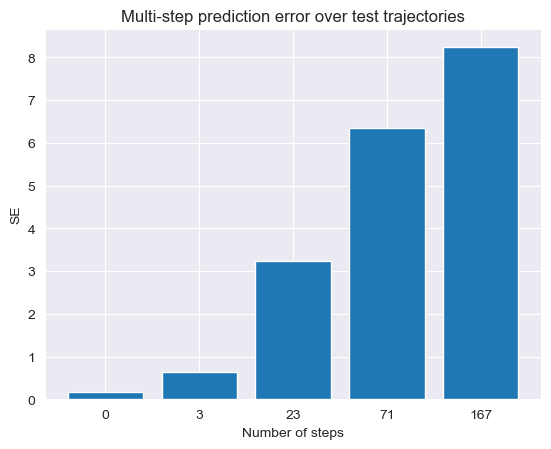

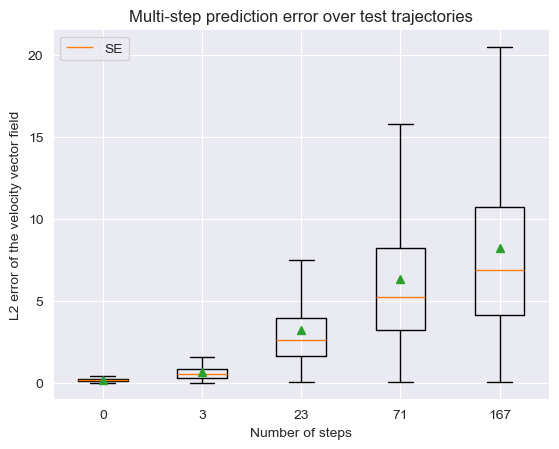

In [57]:
# Plot DMD
plot_multistep_error_barplot(y_true_dmd[::, n_steps],
                             pred_dmd[::, n_steps],
                             title = f"Multi-step prediction error over test trajectories",
                             steps = n_steps, method = "dmd")
plot_multistep_error_boxplot(y_true_dmd[::, n_steps],
                             pred_dmd[::, n_steps],
                             title = "Multi-step prediction error over test trajectories",
                             steps = n_steps, method = "dmd")


In [ ]:
# Plot FNO
plot_multistep_error_barplot(y_true_fno[::, n_steps],
                             pred_fno[::, n_steps],
                             title = f"Multi-step prediction error over test trajectories",
                             steps = n_steps, method = "fno")
plot_multistep_error_boxplot(y_true_fno[::, n_steps],
                             pred_fno[::, n_steps],
                             title = "Multi-step prediction error over test trajectories",
                             steps = n_steps, method = "fno")

In [ ]:
# Plot TFNO
plot_multistep_error_barplot(y_true_tfno[::, n_steps],
                             pred_tfno[::, n_steps],
                             title = f"Multi-step prediction error over test trajectories",
                             steps = n_steps, method = "tfno")
plot_multistep_error_boxplot(y_true_tfno[::, n_steps],
                             pred_tfno[::, n_steps],
                             title = "Multi-step prediction error over test trajectories",
                             steps = n_steps, method = "tfno")

## Multi-step prediction - comparison

In [69]:
#pred.shape -> (4, 168, 2, 128, 256)
methods = ["PCA + DMD", "LatentFNO", "TFNO"]

models_pred = {
    "PCA + DMD": pred_dmd[::, n_steps],
    "LatentFNO": pred_fno[::, n_steps],
    "TFNO": pred_tfno[::, n_steps]
}

models_truth = {
    "PCA + DMD": y_true_dmd[::, n_steps],
    "LatentFNO": y_true_fno[::, n_steps],
    "TFNO": y_true_tfno[::, n_steps]
}

[  0   3  23  71 167]


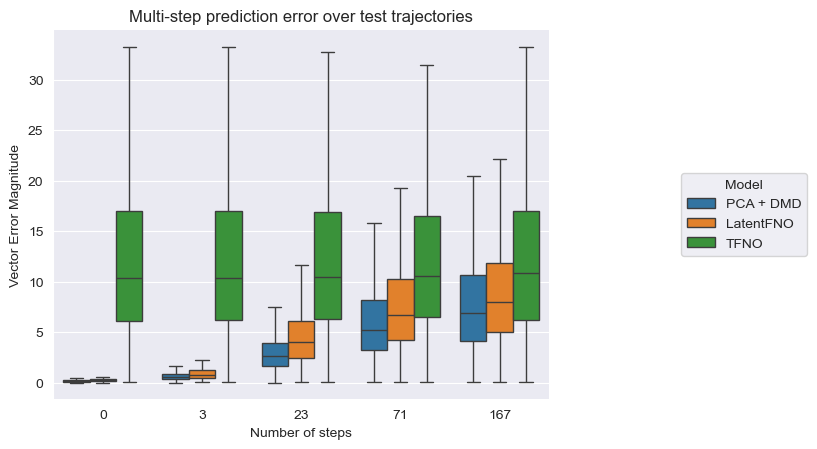

In [94]:
plot_multistep_comparison_boxplot(models_truth, models_pred, methods,
                                  title = f"Multi-step prediction error over test trajectories",
                                  steps = n_steps)

## Loss function for learning process

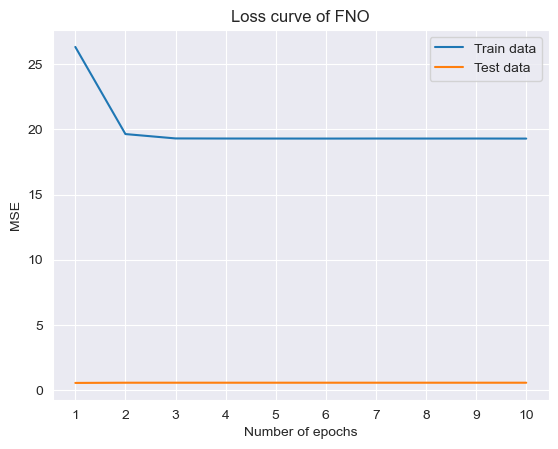

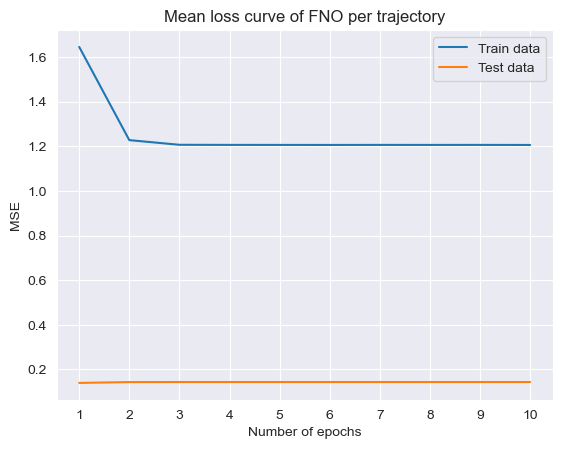

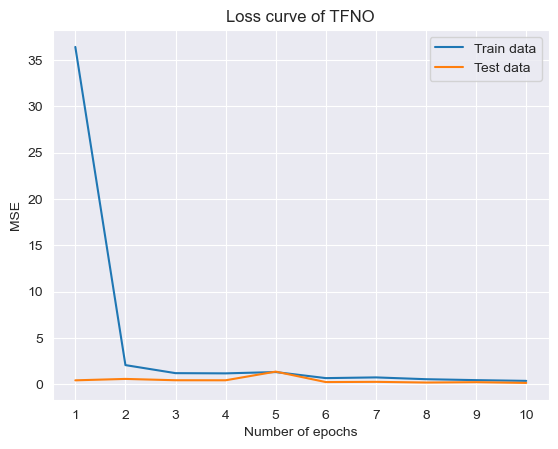

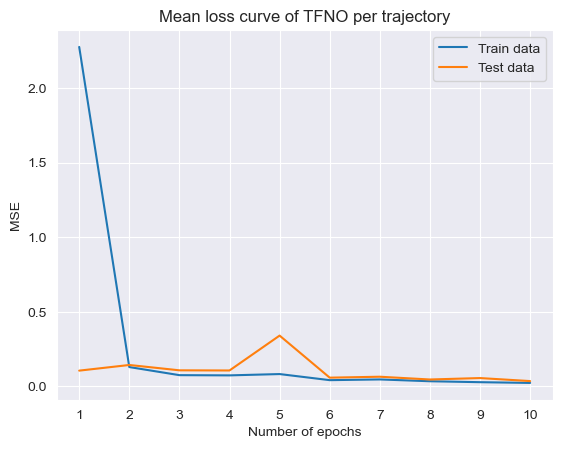

In [21]:
methods = ["fno", "tfno"]

for m in methods:
    path = "results/" + m + "/loss_history.csv"
    data = pd.read_csv(path)
    plot_loss_curve(data, m, f"Loss curve of {m.upper()}")
    plot_loss_curve(data, m, f"Mean loss curve of {m.upper()} per trajectory", mean = True)

## Mean 1-step prediction error over region

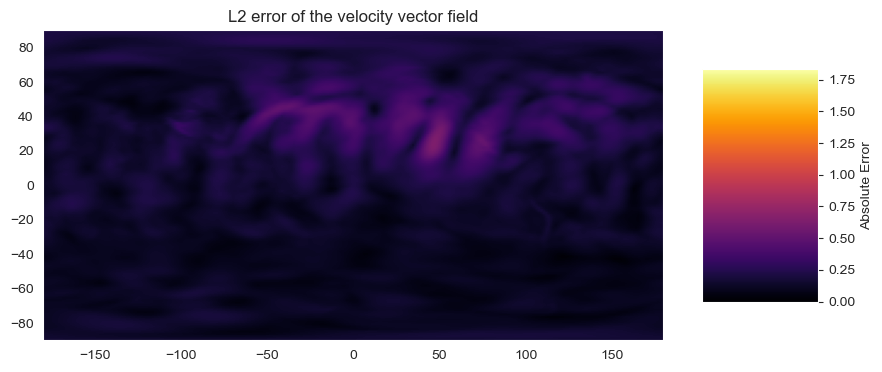

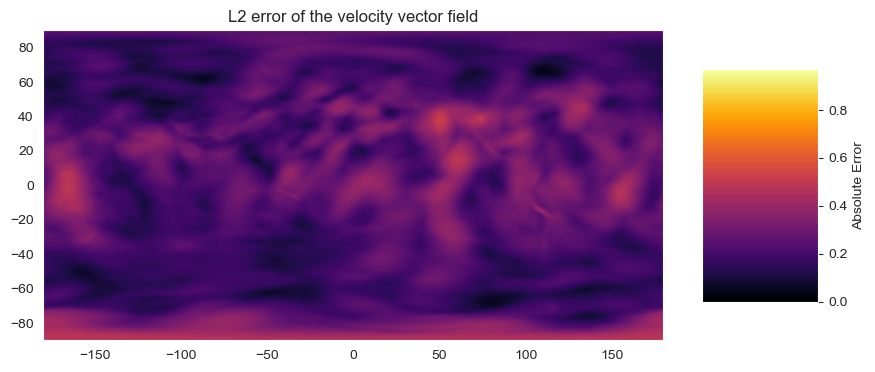

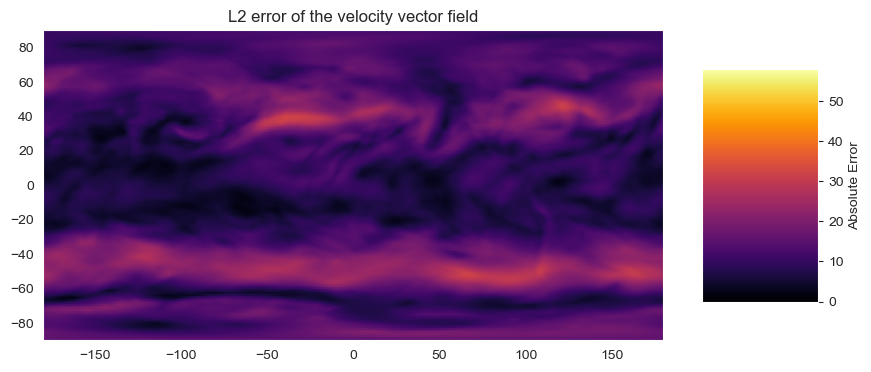

In [129]:
plot_mean_nstep_error_map("dmd", y_true_dmd[::, 0], pred_dmd[::, 0])
plot_mean_nstep_error_map("dmd", y_true_fno[::, 0], pred_fno[::, 0])
plot_mean_nstep_error_map("dmd", y_true_tfno[::, 0], pred_tfno[::, 0])